## DFT vs. MLIPs Energy Comparison Pipeline

This notebook compares MLIP-predicted energies and forces against DFT reference calculations. For each frame in a DFT trajectory, the MLIP takes the DFT-computed structure (atomic positions, cell) as input and performs a single-point evaluation, predicting E and F(r) for that fixed, pre-relaxed geometry. 

The question this tries to answer is: *Given the same structure DFT saw, how close are the MLIP energies and forces?*

Comparison plots are then generated for raw potential energy, relative energy along the trajectory, and adsorption energy (E_ads = E_tot − E_slab − E_gas).

Currently, models used are MACE, MatterSim, and UMA (each run by a script in `model-scripts`).

Note: Although the MLIPs models below are not trained on magnetic field data, magnetically-perturbed DFT data was given and used when constructing the pipeline.

**Future Work**

* [ ] Make parameters/code that handles magnetic data optional (so the pipeline works with non-magnetized DFT runs)
* [ ] Add some I/O handling for the `# DON'T RUN ME` cells so when you press "Run All", the program stops before those cells and asks the user if they'd like to run or skip them (check out the ipywidgets library for this)
* [ ] Address some of the other misc. feedback given on Wednesday's meeting (see notes below)


In [ ]:
# 12 plots instead of 4 (separate out models)
# try MAE by subtracting out different model/dft baselines and running MAE on that
# to consider: when doing E_adsorption, make sure E_total is on the same scale, or it might not work well?

#### 0. Configuration

In [ ]:
from pathlib import Path
import numpy as np
from ase.io import iread, read, write

In [ ]:
# construct data structure used to hold user input

# builds dict describing 1 DFT run (adsorbate system, slab, gas reference).
# the inner path() helper function resolves file paths:
#   - if a full path is given (contains '/'), use it directly
#   - otherwise, construct the standard path under dft-data/
# this lets you override individual paths without changing the defaults.

def make_run(label, bext, ads=None, slab=None, gas=None):
    def path(snippet, default):
        if snippet and '/' in snippet:
            return snippet  # fully specified path, use as-is
        name = snippet or label + default
        return f"dft-data/{name}_BEXT{bext}/vasprun.xml"
    return {
        "label": label,
        "bext":  bext,
        "ads":   path(ads,  "diss2"),
        "slab":  path(slab, "surf"),
        "gas":   path(gas,  "mag2"),
    }

In [ ]:
# ==================================================
# USER INPUT HERE - edit add new DFT runs or models
# ==================================================

# RUNS: one entry per DFT run. make_run(label, bext) where label is typically
# the adsorbate name; pass slab= or gas= for a clean slab or unattached adsorbate
RUNS = ([make_run("NH3", b) for b in [0.1, 0.24, 0.37, 0.5]] +
        [make_run("H2", b, slab="NH3surf", gas="dft-data/H2_gas/vasprun.xml") for b in [0.1, 0.24, 0.37, 0.5]]
)

# MODELS: each entry is (display name, path to that model's python interpreter, runner script).
# each MLIP lives in its own conda env to avoid dependency conflicts.
MODELS = [
        ("MACE",       "/Users/zschwab/miniconda3/envs/mlip-mace/bin/python",       "model-scripts/run_mace.py"),
        ("MatterSim",  "/Users/zschwab/miniconda3/envs/mlip-mattersim/bin/python",  "model-scripts/run_mattersim.py"),
        ("UMA",        "/Users/zschwab/miniconda3/envs/mlip-uma/bin/python",        "model-scripts/run_uma.py"),
]

#### 1. DFT data ingestion

In [ ]:
# load vasp trajectories into ASE Atoms obj.

# for trajectory files with multiple steps
def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    return frames

# for single-structure files (slab reference, gas reference)
def load_frame(path):
    frame = read(path)
    return frame

In [ ]:
# DON'T RUN ME! (unless you want to rerun the models)

# converts DFT trajectories -> .xyz files for MLIP runner scripts to read
# writes .xyz output files to hold model results later
for run in RUNS:
    run_id = f"{run['label']}_BEXT{run['bext']}"
    
    run["xyz_ads"]  = f"model-scripts/script-data/input_ads_{run_id}.xyz"
    run["xyz_slab"] = f"model-scripts/script-data/input_slab_{run_id}.xyz"
    run["xyz_gas"]  = f"model-scripts/script-data/input_gas_{run_id}.xyz"

    write(run["xyz_ads"],  load_frames(run["ads"]))
    write(run["xyz_slab"], load_frame (run["slab"]))
    write(run["xyz_gas"],  load_frame (run["gas"]))

#### 2. run MLIPs (MACE, MatterSim, UMA)

In [ ]:
# DON'T RUN ME! (unless you want to rerun the models)

# runs each MLIP runner script as a subprocess using that model's own conda env
# each script reads the .xyz inputs and writes a .npz file (numpy filetype) 
# with predicted E, F(r)

import subprocess
import os

# new env inherits current environment as a starting point
env = os.environ.copy()

# disable GUI dependencies vscode auto-imports when launching a subprocess from
# a python notebook b/c they conflict with model dependencies and are unneeded
env["MPLBACKEND"] = "Agg"

for run in RUNS:
    run_id = f"{run['label']}_BEXT{run['bext']}"
    run["results"] = {}
    for name, python, script in MODELS:
        out = f"model-scripts/script-data/results_{name}_{run_id}.npz"
        r = subprocess.run(
            [python, script, run["xyz_ads"], run["xyz_slab"], run["xyz_gas"], out],
            capture_output=True, text=True, env=env
        )
        run["results"][name] = out
        if (r.returncode != 0):
            print(f"-- [{run_id}] ({name}): failed")
            if r.stdout: print(r.stdout)
            if r.stderr: print(r.stderr)
            print("Return code:", r.returncode)
        print(f"-- [{run_id}] ({name}): success")

-- [NH3_BEXT0.1] (MACE): success
-- [NH3_BEXT0.1] (MatterSim): success
-- [NH3_BEXT0.1] (UMA): success
-- [NH3_BEXT0.24] (MACE): success
-- [NH3_BEXT0.24] (MatterSim): success
-- [NH3_BEXT0.24] (UMA): success
-- [NH3_BEXT0.37] (MACE): success
-- [NH3_BEXT0.37] (MatterSim): success
-- [NH3_BEXT0.37] (UMA): success
-- [NH3_BEXT0.5] (MACE): success
-- [NH3_BEXT0.5] (MatterSim): success
-- [NH3_BEXT0.5] (UMA): success
-- [H2_BEXT0.1] (MACE): success
-- [H2_BEXT0.1] (MatterSim): success
-- [H2_BEXT0.1] (UMA): success
-- [H2_BEXT0.24] (MACE): success
-- [H2_BEXT0.24] (MatterSim): success
-- [H2_BEXT0.24] (UMA): success
-- [H2_BEXT0.37] (MACE): success
-- [H2_BEXT0.37] (MatterSim): success
-- [H2_BEXT0.37] (UMA): success
-- [H2_BEXT0.5] (MACE): success
-- [H2_BEXT0.5] (MatterSim): success
-- [H2_BEXT0.5] (UMA): success


In [ ]:
# RUN ME INSTEAD (to reconstruct RUNS from saved outputs)

# repopulates each run dict with data stored in the .xyz/.npz files
# without having to re-run any models 
for run in RUNS:
    run_id = f"{run['label']}_BEXT{run['bext']}"
    run["xyz_ads"]  = f"model-scripts/script-data/input_ads_{run_id}.xyz"
    run["xyz_slab"] = f"model-scripts/script-data/input_slab_{run_id}.xyz"
    run["xyz_gas"]  = f"model-scripts/script-data/input_gas_{run_id}.xyz"
    run["results"]  = {
        name: f"model-scripts/script-data/results_{name}_{run_id}.npz"
        for name, *_ in MODELS
    }

#### 3. plot results (model E<sub>slab+ads</sub> vs. DFT E<sub>slab+ads</sub>)

In [7]:
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from itertools import groupby

col_w = 5

# group runs by label to preserve order
labels = list(dict.fromkeys(r["label"] for r in RUNS))
runs_by_label = {lbl: [r for r in RUNS if r["label"] == lbl] for lbl in labels}

In [ ]:
# read DFT energies from saved XYZ files into each run dict
# slab_energy and gas_energy are single reference values used to compute E_ads later

for run in RUNS:
    frames = read(run["xyz_ads"], index=":")
    run["dft"] = {
        "energies":    np.array([a.get_potential_energy() for a in frames]),
        "slab_energy": read(run["xyz_slab"]).get_potential_energy(),
        "gas_energy":  read(run["xyz_gas"]).get_potential_energy(),
    }

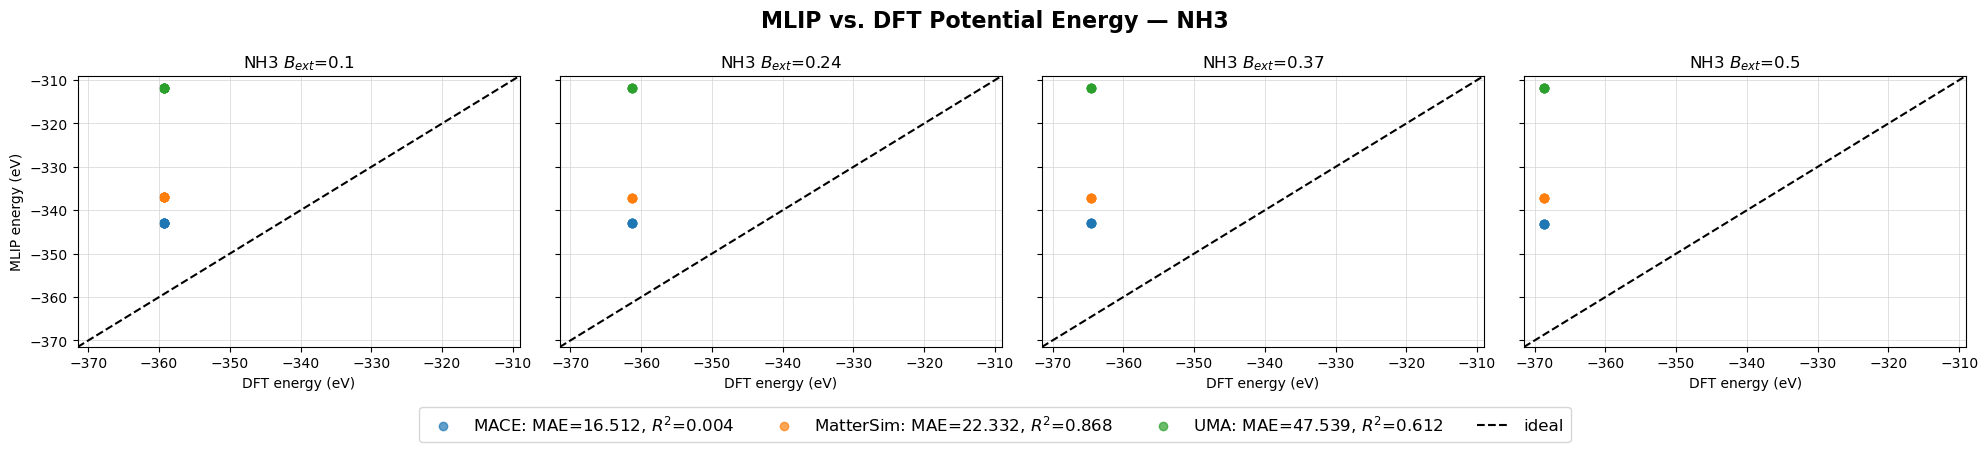

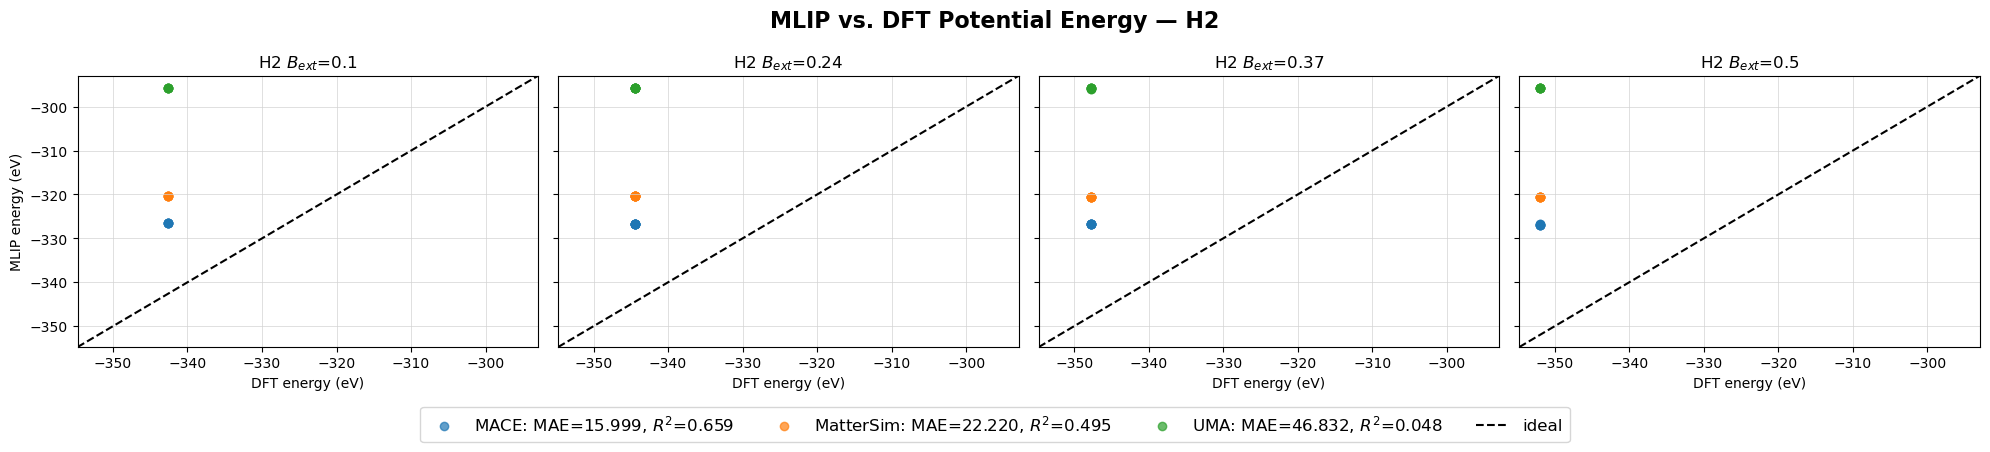

In [46]:
# --- Figure(s) 1: Parity ---
for lbl, label_runs in runs_by_label.items():
    ncols = min(len(label_runs), 4)
    nrows = math.ceil(len(label_runs) / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4.5), dpi=100)
    axes = np.array(axes).flatten()
    fig.suptitle(f"MLIP vs. DFT Potential Energy — {lbl}", fontsize=16, fontweight='semibold')

    all_e = [e for run in label_runs
                for name, *_ in MODELS
                for e in [run["dft"]["energies"],
                            np.load(run["results"][name])["mlip_energies"]]]
    gmin = min(e.min() for e in all_e)
    gmax = max(e.max() for e in all_e)
    pad  = (gmax - gmin) * 0.05
    gmin -= pad; gmax += pad

    for i, run in enumerate(label_runs):
        ax = axes[i]
        dft_e = run["dft"]["energies"]
        for j, (name, *_) in enumerate(MODELS):
            color = plt.cm.tab10(j)
            mlip_e = np.load(run["results"][name])["mlip_energies"]
            
            mae = np.mean(np.abs(mlip_e - dft_e))
            r2  = pearsonr(dft_e, mlip_e).statistic ** 2  # use pearson r^2 b/c insensitive to different energy offsets
            ax.scatter(dft_e, mlip_e, alpha=0.7, color=color,
                        label=f"{name}: MAE={mae:.3f}, $R^2$={r2:.3f}")
        ax.plot([gmin, gmax], [gmin, gmax], 'k--', label="ideal")
        ax.set_xlim(gmin, gmax); ax.set_ylim(gmin, gmax)
        ax.grid(color='lightgrey', linewidth=0.5)
        ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
        ax.set_xlabel("DFT energy (eV)")
        if i % ncols == 0:
            ax.set_ylabel("MLIP energy (eV)")
        else:
            ax.set_yticklabels([])

    for ax in axes[len(label_runs):]:
        ax.set_visible(False)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', ncol=len(MODELS)+1,
                bbox_to_anchor=(0.5, 0.0), fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

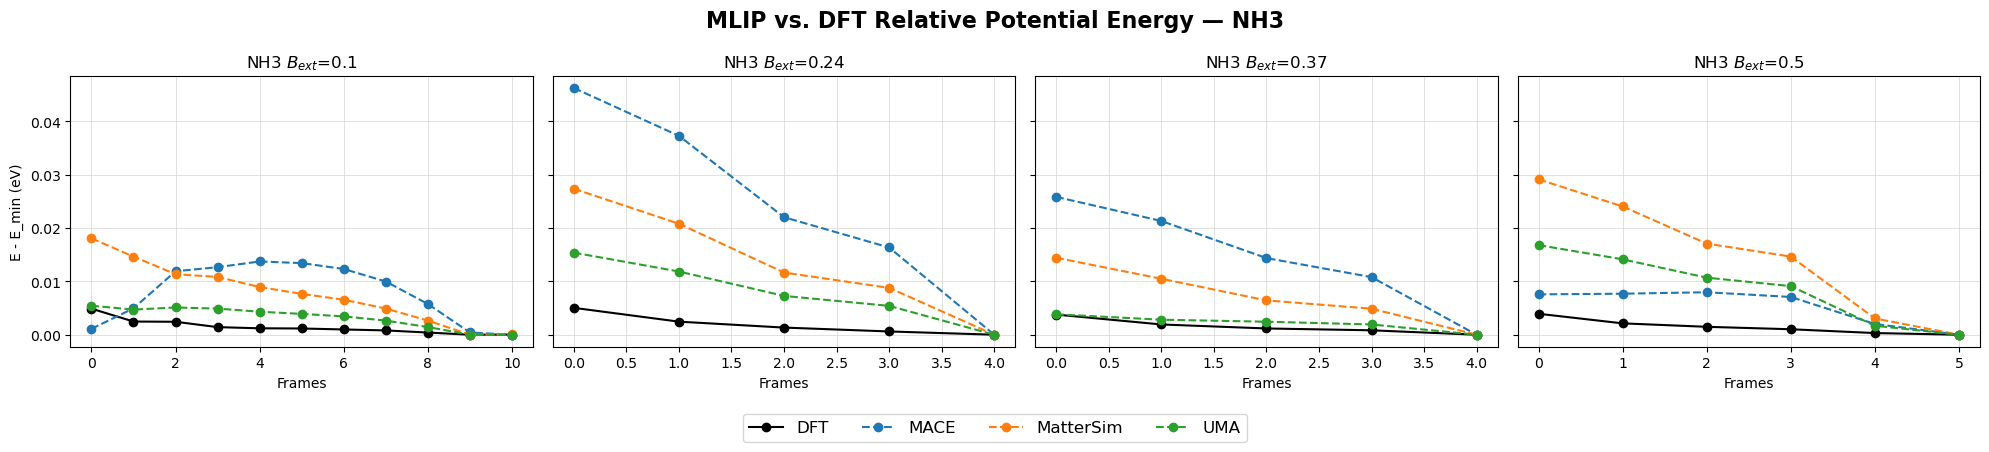

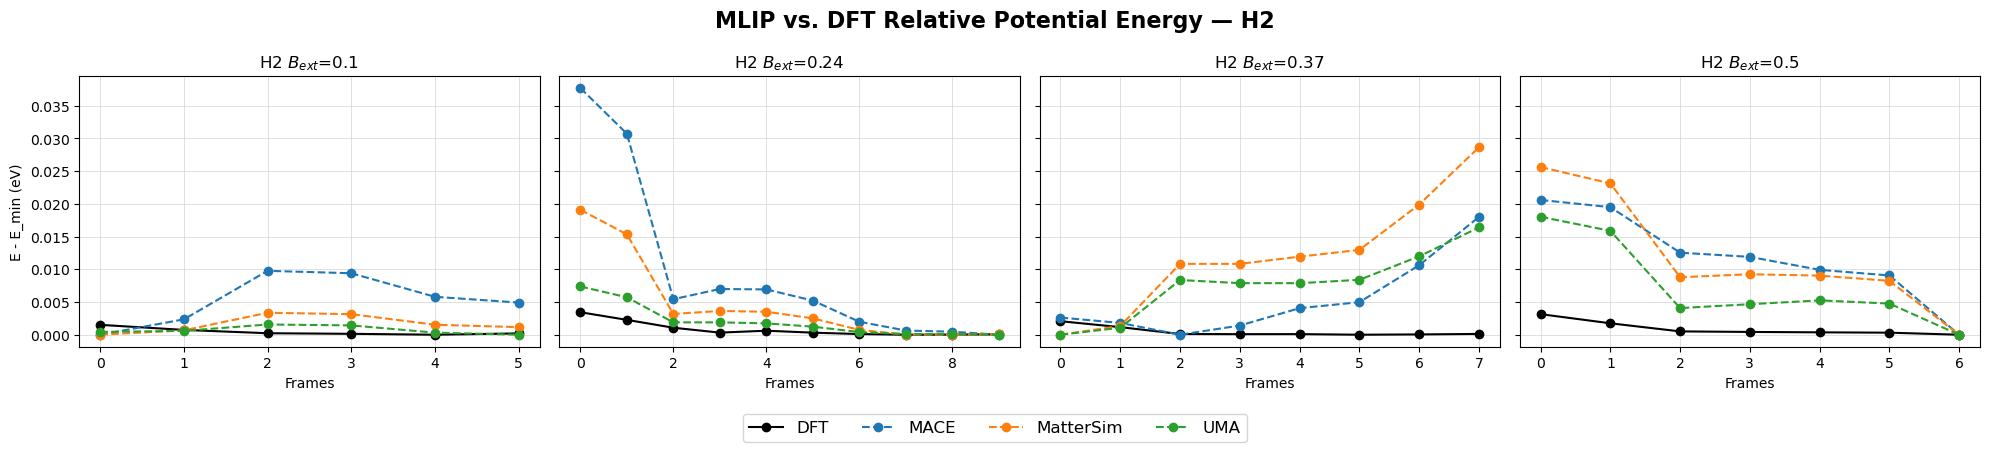

In [ ]:
# --- Figure(s) 2: Relative Energy ---
for lbl, label_runs in runs_by_label.items():
    ncols = min(len(label_runs), 4)
    nrows = math.ceil(len(label_runs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4.5), dpi=100)
    axes = np.array(axes).flatten()
    fig.suptitle(f"MLIP vs. DFT Relative Potential Energy — {lbl}", fontsize=16, fontweight='semibold')

    all_rel = []
    for run in label_runs:
        dft_e = run["dft"]["energies"]
        all_rel.append(dft_e - dft_e.min())
        for name, *_ in MODELS:
            mlip_e = np.load(run["results"][name])["mlip_energies"]
            all_rel.append(mlip_e - mlip_e.min())
    rel_min = min(e.min() for e in all_rel)
    rel_max = max(e.max() for e in all_rel)
    pad = (rel_max - rel_min) * 0.05
    rel_min -= pad; rel_max += pad

    for i, run in enumerate(label_runs):
        ax = axes[i]
        dft_e = run["dft"]["energies"]
        dft_rel = dft_e - dft_e.min()
        frames = range(len(dft_e))
        ax.plot(frames, dft_rel, 'k-o', label="DFT")
        for j, (name, *_) in enumerate(MODELS):
            color = plt.cm.tab10(j)
            mlip_e = np.load(run["results"][name])["mlip_energies"]
            ax.plot(frames, mlip_e - mlip_e.min(), '--o', color=color, label=name)
        ax.set_ylim(rel_min, rel_max)
        ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
        ax.set_xlabel("Frames")
        ax.grid(color='lightgrey', linewidth=0.5)
        if i % ncols == 0:
            ax.set_ylabel("E - E_min (eV)")
        else:
            ax.set_yticklabels([])

    for ax in axes[len(label_runs):]:
        ax.set_visible(False)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', ncol=len(MODELS)+1,
               bbox_to_anchor=(0.5, 0.0), fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

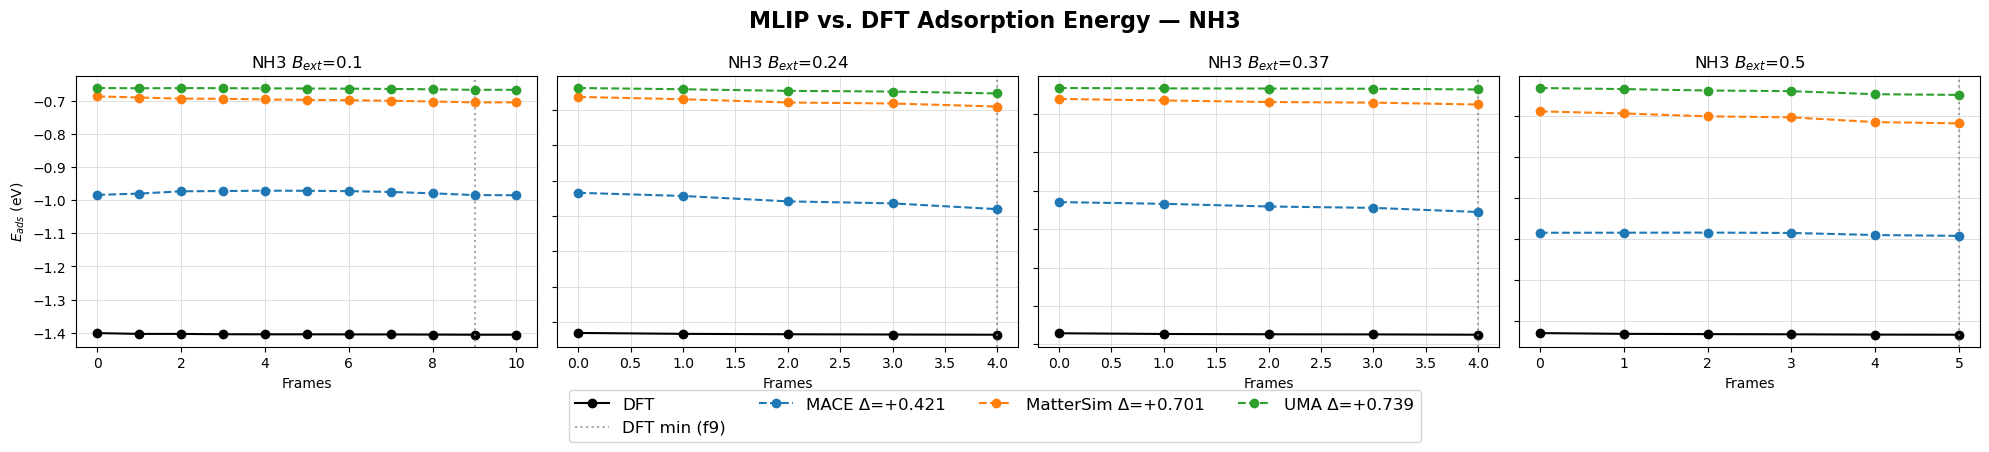

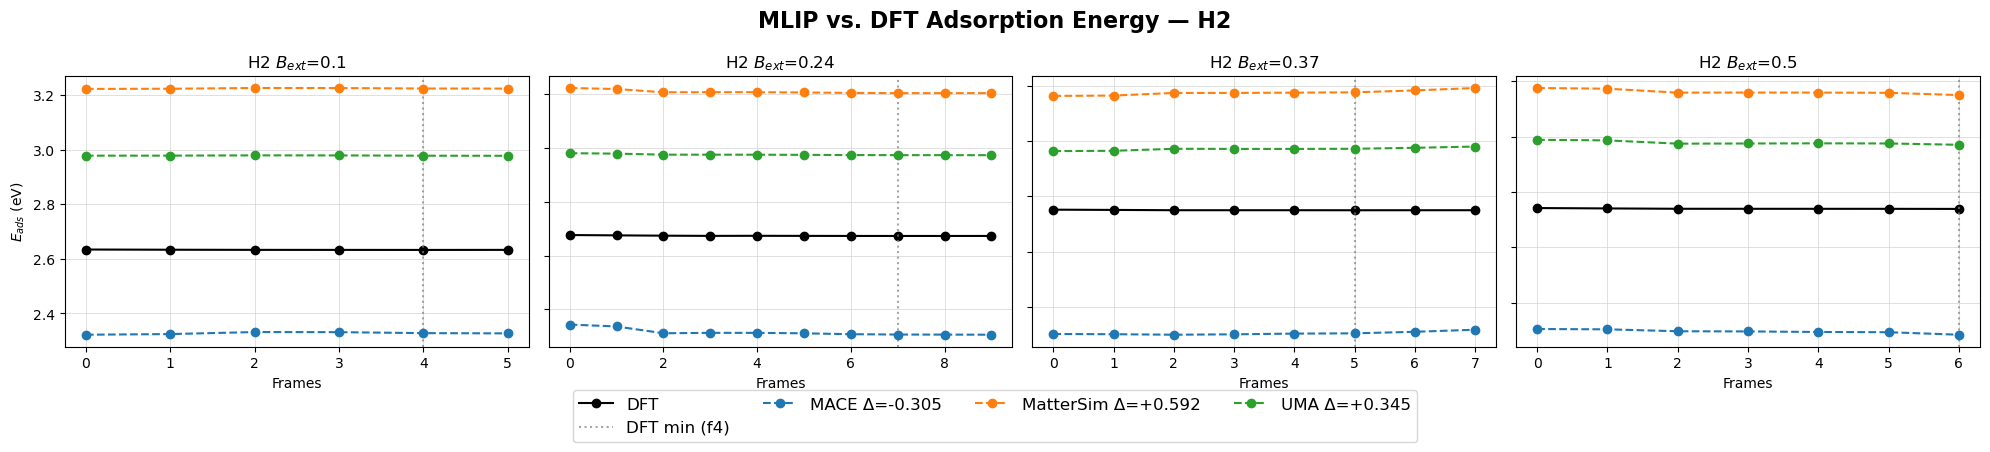

In [43]:
# --- Figure(s) 3: Adsorption Energy ---
for lbl, label_runs in runs_by_label.items():
    ncols = min(len(label_runs), 4)
    nrows = math.ceil(len(label_runs) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4.5), dpi=100)
    axes = np.array(axes).flatten()
    fig.suptitle(f"MLIP vs. DFT Adsorption Energy — {lbl}", fontsize=16, fontweight='semibold')

    for i, run in enumerate(label_runs):
        ax = axes[i]
        dft_e   = run["dft"]["energies"]
        dft_ads = dft_e - run["dft"]["slab_energy"] - run["dft"]["gas_energy"]
        dft_min = np.argmin(dft_ads)
        frames  = range(len(dft_e))
        ax.plot(frames, dft_ads, 'k-o', label="DFT")
        ax.axvline(dft_min, color='gray', linestyle=':', alpha=0.7, label=f"DFT min (f{dft_min})")
        for j, (name, *_) in enumerate(MODELS):
            color    = plt.cm.tab10(j)
            res      = np.load(run["results"][name])
            mlip_ads = res["mlip_energies"] - res["slab_energy"] - res["gas_energy"]
            err      = mlip_ads[dft_min] - dft_ads[dft_min]
            ax.plot(frames, mlip_ads, '--o', color=color, label=f"{name} Δ={err:+.3f}")
        ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
        ax.set_xlabel("Frames")
        ax.grid(color='lightgrey', linewidth=0.5)
        if i % ncols == 0:
            ax.set_ylabel("$E_{ads}$ (eV)")
        else:
            ax.set_yticklabels([])

    for ax in axes[len(label_runs):]:
        ax.set_visible(False)

    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower center', ncol=len(MODELS)+1,
                bbox_to_anchor=(0.5, 0.0), fontsize=12)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()